# Developing history of v2
Seungwon | July 2025

In [23]:
import sys
import os

# Go up one directory from the 'notebooks' folder.
parent_dir = os.path.abspath(os.path.join('..'))
sys.path.append(parent_dir)
from my_package.module import *
from my_package.pulse_manager import *
from my_package.pulse_manager_v2 import *

from qutip import *             #version 5.1.1
import dynamiqs as dq           #version 0.3.2
import qctrlvisualizer as qv    #version 0.3.2
import boulderopal as bo
import numpy as np              #version 1.26.4
from math import pi, sqrt, exp, cos, sin

'waveform_generator()' function returns a list of 

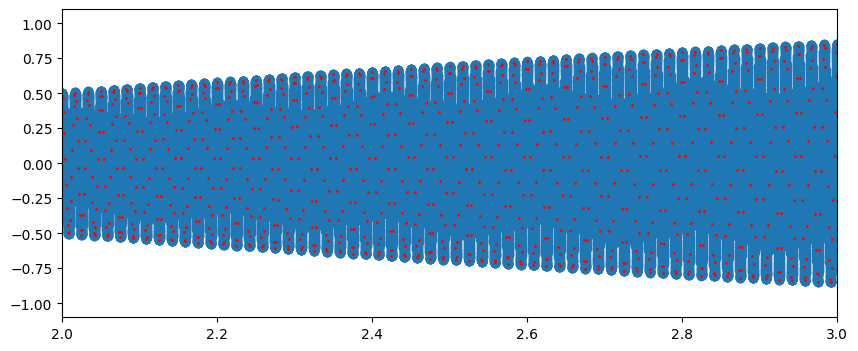

In [22]:
t, w = waveform_generator(
    frequency=60e9,
    length=10e-9,
    dt= 0.0001e-9,
    envelope="flat_top",
    rise_time = 4e-9
    # , bins=(400e-9, 200e-9)   # (start, duration)
)

plt.figure(figsize=(10, 4))
plt.scatter(t*1e9, w)
t_in = np.linspace(0, 10e-9, 10001)
plt.scatter(t_in*1e9, np.interp(t_in, t, w), color='red', s=1)
plt.xlim(2, 3)
plt.show()

# pulse_manager_v2 demos

[1] every pulse manaer functions returns 'time steps' and 'waveforms' \
[2] each return is in the form of list(numpy.ndarry)

In [ ]:
t, w = waveform_generator(
    frequency=6e9,
    length=5e-9,
    dt= 0.005/6e9,
    # envelope="square"
    envelope="gaussian",
    # , bins=(400e-9, 200e-9)   # (start, duration)
)

tt, ww = waveform_generator(
    frequency=6e9,
    length=5e-9,
    dt= 0.2/6e9,
    envelope="square"
    # , bins=(400e-9, 200e-9)   # (start, duration)
)

plt.figure(figsize=(10, 4))
plt.plot(t*1e9, w)
plt.plot(tt*1e9, ww, linestyle='--', color='orange')
plt.show()

# Assume t and w already defined from waveform_generator
dt = (t[1] - t[0])  # Time step
N = t.size*10
dtt = (tt[1] - tt[0])  # Time step for square pulse
NN = tt.size*10

# Compute FFT (shifted for symmetry around zero frequency)
W = np.fft.fft(w, n=N)
freqs = np.fft.fftfreq(N, dt)
WW = np.fft.fft(ww, n=NN)
ffreqs = np.fft.fftfreq(NN, dtt)

# Shift for plotting (optional, to center zero freq)
W_shifted = np.fft.fftshift(W)
freqs_shifted = np.fft.fftshift(freqs)
WW_shifted = np.fft.fftshift(WW)
ffreqs_shifted = np.fft.fftshift(ffreqs)

# Plot the magnitude spectrum
plt.figure(figsize=(8,4))
plt.scatter(freqs_shifted/1e6, np.abs(W_shifted)/np.max(np.abs(W_shifted)))
plt.scatter(ffreqs_shifted/1e6, np.abs(WW_shifted)/np.max(np.abs(WW_shifted)), color='orange', label='Square Pulse')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Normalized Amplitude')
plt.title('Fourier Transform of Pulse')

plt.xlim(6000-2000, 6000+2000)

In [ ]:
# 2) Same idea, but two separate silent windows
t2, w2 = waveform_generator(
    100e6, 1e-6, 1e-9, "flat_top",
    Amplitude = 3
    # , bins=[(200e-9, 50e-9), (750e-9, 100e-9)]
)
plt.plot(t2*1e9, w2)
plt.show()

# Assume t and w already defined from waveform_generator
dt = t2[1] - t[0]  # Time step
N = t2.size*10

# Compute FFT (shifted for symmetry around zero frequency)
W = np.fft.fft(w2, n=N)
freqs = np.fft.fftfreq(N, dt)

# Shift for plotting (optional, to center zero freq)
W_shifted = np.fft.fftshift(W)
freqs_shifted = np.fft.fftshift(freqs)

# Plot the magnitude spectrum
plt.figure(figsize=(8,4))
plt.plot(freqs_shifted/1e6, np.abs(W_shifted)/np.max(np.abs(W_shifted)))
plt.xlabel('Frequency (MHz)')
plt.ylabel('Normalized Amplitude')
plt.title('Fourier Transform of Pulse: Normalized')
# plt.xlim(100-20, 100+20)
# plt.axvline(freqs_shifted[np.abs(W_shifted).argmax()]/1e6, color='red', linestyle='--', label='Max Frequency')


# 2) Same idea, but two separate silent windows
t2, w2 = waveform_generator(
    100e6, 2e-6, 1e-9, "flat_top",
    Amplitude = 3
    # , bins=[(200e-9, 50e-9), (750e-9, 100e-9)]
)

# Assume t and w already defined from waveform_generator
dt = t2[1] - t[0]  # Time step
N = t2.size*10

# Compute FFT (shifted for symmetry around zero frequency)
W = np.fft.fft(w2, n=N)
freqs = np.fft.fftfreq(N, dt)

# Shift for plotting (optional, to center zero freq)
W_shifted = np.fft.fftshift(W)
freqs_shifted = np.fft.fftshift(freqs)

# Plot the magnitude spectrum
plt.plot(freqs_shifted/1e6, np.abs(W_shifted)/np.max(np.abs(W_shifted)))
plt.xlim(100-20, 100+20)
# plt.axvline(freqs_shifted[np.abs(W_shifted).argmax()]/1e6, color='red', linestyle='--', label='Max Frequency')
plt.show()

In [ ]:
# Custom envelope
def custom_env(t):
    env = np.ones_like(t)
    env *= np.sin(np.pi * t / t[-1])**2  # sin^2 envelope
    return env

t, wave = waveform_generator(500e6, 100e-9, 0.1e-9, envelope=custom_env)
# t_in = np.linspace(0, 100e-9, len(t)\)
# plt.scatter(t_in*1e9, np.interp(t_in, t, w), color='red', s=1)
plt.plot(t*1e9, wave)

In [ ]:
# --- 2) Concatenate into a single drive ----------------------------
t0, w0 = waveform_generator(
    50e6, 1e-6, 1e-9, "flat_top",
)

# fake waveform window
t1, w1 = waveform_generator(
    50e6, 1e-6, 1e-9, "flat_top", bins=(0, 1e-6)
)

t2, w2 = waveform_generator(
    50e6, 1e-6, 1e-9, "flat_top",
)

t_long, w_long = combine_waveforms([(t0, w0), (t1, w1), (t2, w2)], mode="concatenate")

plt.figure(figsize=(10, 4))
# plt.plot(t_long*1e9, w_long)

t_in = np.linspace(0, t_long[-1], len(t_long)*1)
plt.plot(t_in*1e9, np.interp(t_in, t_long, w_long), color='red', )
# plt.xlim(500,1000)

In [ ]:
t_long[-1]

Hamiltonian_dispersive(dim_c, dim_q, w_c, w_q, K_c, K_q, chi_cq, kappa_c, kappa_q, plotter)

$H_{disp}=\omega_c a^\dagger a - \frac{K_c}{2} a^\dagger a^\dagger a a + \omega_q b^\dagger b - \frac{K_q}{2} b^\dagger b^\dagger b b + \chi_{cq} a^\dagger a b^\dagger b$

$ H = H_{cavity} \otimes H_{qubit}$

In [ ]:
# Self-Kerr effect: nature11902
# stroage cavity, qubit(transmon)
dim_c= 10
dim_q= 7
# energies
w_c = 2*np.pi*9274.7e6
w_q = 2*np.pi*7850.3e6
# self-Kerr
K_c = 2*np.pi*0.325e6
K_q = 2*np.pi*73.4e6
# cross-Kerr
chi_cq = 2*np.pi*9.4e6
# relaxation rate
kappa_c = 1/436e-6
kappa_q = 1/30e-6

# Hamiltonian
H0, c_ops, H_drive_cavity, H_drive_qubit = Hamiltonian_dispersive(dim_c, dim_q, w_c, w_q, K_c, K_q, chi_cq, kappa_c, kappa_q, plotter=False)

# Population of each energy level in the product space H0
observables = Observables(H0)




A = 1e6*(2*pi)
# t_length = np.pi/A
t_length = 500e-9
res_freq = w_c

t, w = waveform_generator(
    frequency= res_freq/(2*pi),  # Frequency in Hz
    length=t_length,
    dt= 0.01e-9,
    envelope="square",
    Amplitude=A*10
)
dt = t[1] - t[0]  # Time step
N = t.size*10
W = np.fft.fft(w, n=N)
freqs = np.fft.fftfreq(N, dt)
W_shifted = np.fft.fftshift(W)
freqs_shifted = np.fft.fftshift(freqs)
plt.figure(figsize=(10, 4))
plt.plot(freqs_shifted/1e6, np.abs(W_shifted)/A)
plt.xlim(freqs_shifted[np.argmax(np.abs(W_shifted))]/1e6-100, freqs_shifted[np.argmax(np.abs(W_shifted))]/1e6+100)
plt.axvline(res_freq/1e6, color='red', linestyle='--', label='Qubit Frequency')
plt.show()

interpolated = np.interp(np.linspace(0, t[-1], len(t)), t, w)


phi0 = tensor(
    basis(dim_c, 0),  # Cavity ground state
    basis(dim_q, 0)   # Qubit ground state
)

result = mesolve(
    [H0, [H_drive_cavity, interpolated]],
    phi0,
    # tlist=np.linspace(0, t_length, 10001),  # Time vector
    t,
    c_ops = [],
    e_ops = observables
    )

plt.plot(t*1e9,result.expect[0],label='0g')
plt.plot(t*1e9,result.expect[1],label='0e')
plt.plot(t*1e9,result.expect[2],label='1g')
plt.plot(t*1e9,result.expect[3],label='0f')
plt.plot(t*1e9,result.expect[4],label='1e')
plt.plot(t*1e9,result.expect[5],label='2g')
plt.plot(t*1e9,result.expect[6],label='0h')
plt.plot(t*1e9,result.expect[7],label='1f')
plt.plot(t*1e9,result.expect[8],label='2e')
plt.plot(t*1e9,result.expect[9],label='3g')
plt.plot(t*1e9,result.expect[10],label='0i')
# plt.axvline(np.pi/args1['A_qubit']*1e9, color='black', lw=1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Adjust (1, 1) to move the legend
plt.tight_layout()  # Adjust the plot to make room for the legend outside and Ensures the layout doesn't get cut off
plt.xlabel('Time (ns)')
plt.ylabel('Population')

In [ ]:
# Self-Kerr effect: nature11902
# stroage cavity, qubit(transmon)
dim_c= 10
dim_q= 7
# energies
w_c = 2*np.pi*9274.7e6
w_q = 2*np.pi*7850.3e6
# self-Kerr
K_c = 2*np.pi*0.325e6
K_q = 2*np.pi*73.4e6
# cross-Kerr
chi_cq = 2*np.pi*9.4e6
# relaxation rate
kappa_c = 1/436e-6
kappa_q = 1/30e-6

# Hamiltonian
H0, c_ops, H_drive_cavity, H_drive_qubit = Hamiltonian_dispersive(dim_c, dim_q, w_c, w_q, K_c, K_q, chi_cq, kappa_c, kappa_q, plotter=False)

# Population of each energy level in the product space H0
observables = Observables(H0)




A = 2e6
# t_length = np.pi/A
t_length = 10e-6
res_freq = w_c

t, w = waveform_generator(
    frequency= res_freq/(2*pi),  # Frequency in Hz
    length=t_length,
    dt= 0.01e-9,
    envelope="gaussian",
    Amplitude=A*10
)
dt = t[1] - t[0]  # Time step
N = t.size*10
W = np.fft.fft(w, n=N)
freqs = np.fft.fftfreq(N, dt)
W_shifted = np.fft.fftshift(W)
freqs_shifted = np.fft.fftshift(freqs)
plt.figure(figsize=(10, 4))
plt.plot(freqs_shifted/1e6, np.abs(W_shifted)/A)
plt.xlim(freqs_shifted[np.argmax(np.abs(W_shifted))]/1e6-10, freqs_shifted[np.argmax(np.abs(W_shifted))]/1e6+10)
plt.axvline(res_freq/(2*pi)/1e6, color='red', linestyle='--', label='Qubit Frequency')
plt.show()

interpolated = np.interp(np.linspace(0, t[-1], len(t)), t, w)


phi0 = tensor(
    basis(dim_c, 0),  # Cavity ground state
    basis(dim_q, 0)   # Qubit ground state
)

result = mesolve(
    [H0, [H_drive_cavity, interpolated]],
    phi0,
    # tlist=np.linspace(0, t_length, 10001),  # Time vector
    t,
    c_ops = [],
    e_ops = observables
    )

plt.plot(t*1e9,result.expect[0],label='0g')
plt.plot(t*1e9,result.expect[1],label='0e')
plt.plot(t*1e9,result.expect[2],label='1g')
plt.plot(t*1e9,result.expect[3],label='0f')
plt.plot(t*1e9,result.expect[4],label='1e')
plt.plot(t*1e9,result.expect[5],label='2g')
plt.plot(t*1e9,result.expect[6],label='0h')
plt.plot(t*1e9,result.expect[7],label='1f')
plt.plot(t*1e9,result.expect[8],label='2e')
plt.plot(t*1e9,result.expect[9],label='3g')
plt.plot(t*1e9,result.expect[10],label='0i')
# plt.axvline(np.pi/args1['A_qubit']*1e9, color='black', lw=1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Adjust (1, 1) to move the legend
plt.tight_layout()  # Adjust the plot to make room for the legend outside and Ensures the layout doesn't get cut off
plt.xlabel('Time (ns)')
plt.ylabel('Population')

In [ ]:
# Hamiltonian
H0, c_ops, H_drive_cavity, H_drive_qubit = Hamiltonian_dispersive(dim_c=10, 
                                                                  dim_q=7, 
                                                                  w_c=2*np.pi*9274.7e6, 
                                                                  w_q=2*np.pi*7850.3e6, 
                                                                  K_c=2*np.pi*0.325e6, 
                                                                  K_q=2*np.pi*73.4e6, 
                                                                  chi_cq=2*np.pi*9.4e6, 
                                                                  kappa_c=1/436e-6, 
                                                                  kappa_q=1/30e-6, 
                                                                  plotter=False
                                                                  )

# Population of each energy level in the product space H0
observables = Observables(H0)




A = 50e6
# t_length = np.pi/A
t_length = 50e-9
res_freq = w_c

t, w = waveform_generator(
    frequency= res_freq/(2*pi),  # Frequency in Hz
    length=t_length,
    dt= 0.01e-9,
    envelope="gaussian",
    Amplitude=A*10
)
dt = t[1] - t[0]  # Time step
N = t.size*10
W = np.fft.fft(w, n=N)
freqs = np.fft.fftfreq(N, dt)
W_shifted = np.fft.fftshift(W)
freqs_shifted = np.fft.fftshift(freqs)
plt.figure(figsize=(10, 4))
plt.plot(freqs_shifted/1e6, np.abs(W_shifted)/A)
plt.xlim(freqs_shifted[np.argmax(np.abs(W_shifted))]/1e6-10, freqs_shifted[np.argmax(np.abs(W_shifted))]/1e6+10)
plt.axvline(res_freq/(2*pi)/1e6, color='red', linestyle='--', label='Qubit Frequency')
plt.show()

interpolated = np.interp(np.linspace(0, t[-1], len(t)), t, w)


phi0 = tensor(
    basis(dim_c, 0),  # Cavity ground state
    basis(dim_q, 0)   # Qubit ground state
)

result = mesolve(
    [H0, [H_drive_cavity, interpolated]],
    phi0,
    t,
    c_ops = []
    )
Urot = propagator(-H0, t, [], args={})

In [ ]:
state_rf = [Urot[k]*result.states[k] for k in range(len(result.states))]
full_density_matrix = state_rf[-1]*state_rf[-1].dag()
cavity_dm = ptrace(full_density_matrix, 0)

# Define the range for x and p quadratures
xvec = np.linspace(-5, 5, 100)
pvec = np.linspace(-5, 5, 100)
plot_wignerfunction(cavity_dm, xvec, pvec)
plot_fock_distribution(cavity_dm, dim_c)